### Build CSV file for HARPS/NIRPS s1d files

In [ ]:
import os
import numpy as np
import sys
from astropy.io import fits
import astropy.constants as const
sys.path.append('/home/amasson/data/Kaperture_Science/HR-SpARTA_priv/core modules/')

from transits_info import *
from reduction import *


In [87]:
# first we load a dataset from the transit to correct
transit = TOI969_03_2024_HARPS

dd = DataSet()
dd.load_HARPS_data(transit)


Loading files in '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/' :
61 out of 670 files selected !

Building data cube of shape : (61, 72, 4096)
Filling the data cube with selected files...
Function to build HARPS wavelength solution has directly been extracted from the open-source sBART tool (https://github.com/iastro-pt/sBART/): please contact and cite relevant authors!
Note that we arbitrary take the SNR from header corresponding to order 30, as SNR has the same relative behavior along time in all orders
No molecfit telluric correction files found in /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/: CAN'T APPLY TELLURIC CORRECTION !!! RUN MOLECFIT FIRST ON S1D FILES TO GENERATE THE TELLURIC TEMPLATE, THEN STORE THE FILES IN WITH "Telluric_Correction_Molecfit" IN NAME IN SAME FOLDER AS DATA !!

Building the off-transit spectra masked :

61 / 61
Found 45 off-transit spectra among 61 spectra

Find off transit spect

In [ ]:
# now generate a csv files with path to each s1d fits to correct + the redshift of the stellar lines in Earth RF (for excluding stellar lines)
fits_list = [dd.path + f.replace('e2ds','s1d') for f in dd.files] # list of s1d files corresponding to the e2ds files in the dataset
# compute the stellar redshift of each file: this is the redshift to apply to shift a stellar line from stellar RF to Earth RF
z = -1*dd.Vd / const.c.value
# generate csv file
with open(f'./Automated_Program/{dd.name}.csv','w') as f:
    f.write('file,z\n')
    for file,shift in zip(fits_list,z):
        f.write(f'{file},{shift:.8f}\n')
print(f'./Automated_Program/{dd.name}.csv')


./Automated_Program/TOI-969b_HARPS_03-03-2024.csv


In [ ]:
dd.headers[0]


{'Primary header': SIMPLE  =                    T /Primary Header created by MWRFITS v1.12         
 BITPIX  =                    8 /                                                
 NAXIS   =                    0 /                                                
 EXTEND  =                    T / FITS dataset may contain extensions            
 ECHVERS =              1.00000 / version number of echelle data format          
 COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
 COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
 COMMENT   FITS (Flexible Image Transport System) 2010A&A...524..A42P            
 DETSEC  = '[1:4096,1:2048]'    / [px] xrange and yrange of window               
 DETSIZE = '[1:4096,1:2048]'    / [px] x-range, yrange of full frame             
 FILENAME= 'car-20190702T20h55m20s-sci-amap-nir.fits' / Filename by 1st stage pip
 OBJECT  = 'Kepler-91'          / telescope target                              

In [ ]:
# load a s1d FITS to check structure
s1d_file = fits.open(fits_list[3])


In [ ]:
s1d_file.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:16:20.916_s1d_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3348   (312941,)   float32   


In [ ]:
s1d_file[0].data.shape


(312941,)

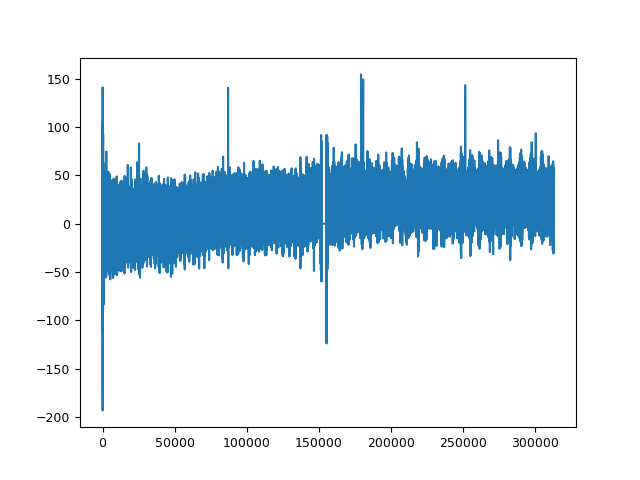

In [ ]:
%matplotlib widget
plt.figure()
plt.plot(s1d_file[0].data)


### Build s1d files for CARMENES data

### Plot results

1) load a transit and associated dataset and generate the CSV with s1d file list for molecfit to process
2) setup the Molecfit_run_parallelized.py parameters (first lines, path to s1d files)
3) run in terminal: $ python Molecfit_run_parallelized.py
4) run cells below to check result

Run dir: /home/amasson/data/molecfit_wrapper/Output/output0__06_05_2026
TAC source: /home/amasson/data/molecfit_wrapper/Output/output0__06_05_2026/HARPS.2024-03-03T23:59:42.310_s1d_A_TAC.dat
Reduced chi2: 10000.0
FWHM (pix): 0.0


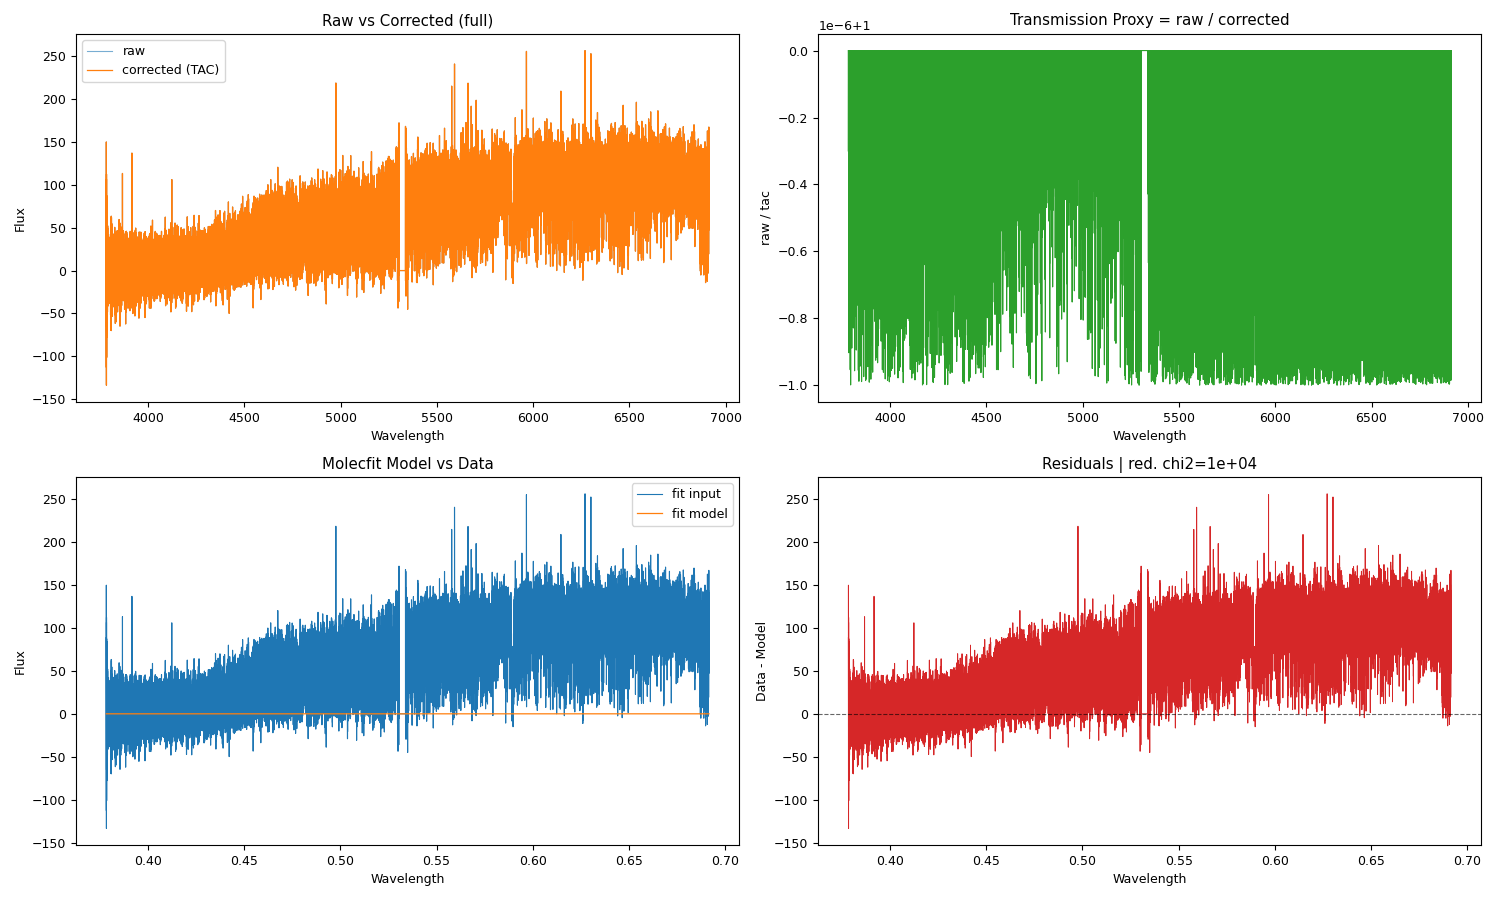

In [139]:
# Cell: load one molecfit run and visualize raw/corrected spectrum + fit quality

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --- configure ---
output_root = "/home/amasson/data/molecfit_wrapper/Output"
spectrum_index = 0  # change if needed

def _find_latest_run_dir(output_root, idx):
    pattern = os.path.join(output_root, f"output{idx}_*")
    cands = [d for d in glob.glob(pattern) if os.path.isdir(d)]
    if not cands:
        raise FileNotFoundError(f"No run directory found with pattern: {pattern}")
    return max(cands, key=os.path.getmtime)

def _read_fit_res_txt(run_dir, idx):
    # e.g. Spectrum_0_fit.res
    p = os.path.join(run_dir, f"Spectrum_{idx}_fit.res")
    out = {"reduced_chi2": np.nan, "fwhm_pix": np.nan}
    if not os.path.exists(p):
        return out
    with open(p, "r") as f:
        for line in f:
            if "Reduced chi2:" in line:
                try:
                    out["reduced_chi2"] = float(line.split()[-1])
                except Exception:
                    pass
            if "FWHM of Gaussian in pixels:" in line:
                try:
                    out["fwhm_pix"] = float(line.split()[-3])
                except Exception:
                    pass
    return out

def _read_input_converted(run_dir, idx):
    # This is the converted input used by molecfit
    p = os.path.join(run_dir, f"Spectrum_{idx}.fits")
    if not os.path.exists(p):
        return None, None
    with fits.open(p) as hdul:
        # robust fallback for possible column naming
        wave, flux = None, None
        for hdu in hdul:
            data = getattr(hdu, "data", None)
            names = getattr(data, "names", None)
            if names:
                up = {n.upper(): n for n in names}
                for k in ["WAVE", "LAMBDA", "WAVELENGTH"]:
                    if k in up:
                        wave = np.array(data[up[k]], dtype=float)
                        break
                for k in ["FLUX", "SPEC", "SPECTRUM"]:
                    if k in up:
                        flux = np.array(data[up[k]], dtype=float)
                        break
                if wave is not None and flux is not None:
                    break
        return wave, flux

def _read_tac(run_dir, idx):
    # Priority 1: ASCII TAC (common for HARPS S1D with wrapper conversion)
    tac_dat = glob.glob(os.path.join(run_dir, "*_TAC.dat"))
    if tac_dat:
        p = sorted(tac_dat)[0]
        arr = np.genfromtxt(p)
        if arr.ndim == 1:
            arr = arr[None, :]
        wave = arr[:, 0]
        raw  = arr[:, 1]
        # wrapper logic: TAC flux usually col 3 or 4 depending format
        tac  = arr[:, 4] if arr.shape[1] > 5 else arr[:, 3]
        return wave, raw, tac, p

    # Priority 2: FITS TAC produced by calctrans
    tac_fits = os.path.join(run_dir, f"Spectrum_{idx}_tac.fits")
    if os.path.exists(tac_fits):
        with fits.open(tac_fits) as hdul:
            data = hdul[1].data
            names = {n.upper(): n for n in data.names}
            wave = np.array(data[names.get("WAVE", data.names[0])], dtype=float)
            raw  = np.array(data[names.get("FLUX", data.names[1])], dtype=float)
            tacn = names.get("TACFLUX", names.get("TAC", data.names[min(2, len(data.names)-1)]))
            tac  = np.array(data[tacn], dtype=float)
        return wave, raw, tac, tac_fits

    raise FileNotFoundError("No TAC file found (*_TAC.dat or Spectrum_i_tac.fits).")

def _read_fit_spectrum(run_dir, idx):
    p = os.path.join(run_dir, f"Spectrum_{idx}_fit.fits")
    if not os.path.exists(p):
        return None, None, None
    with fits.open(p) as hdul:
        d = hdul[1].data
        wave = np.array(d["lambda"], dtype=float)
        flux = np.array(d["flux"], dtype=float)
        model = np.array(d["mflux"], dtype=float)
    return wave, flux, model

# --- load ---
run_dir = _find_latest_run_dir(output_root, spectrum_index)
stats = _read_fit_res_txt(run_dir, spectrum_index)
w_in, f_in = _read_input_converted(run_dir, spectrum_index)
w_tac, f_raw_tac, f_tac, tac_path = _read_tac(run_dir, spectrum_index)
w_fit, f_fit, f_model = _read_fit_spectrum(run_dir, spectrum_index)

print("Run dir:", run_dir)
print("TAC source:", tac_path)
print("Reduced chi2:", stats["reduced_chi2"])
print("FWHM (pix):", stats["fwhm_pix"])

# --- plot ---
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
ax = ax.ravel()

# Panel 1: full raw vs corrected (from TAC file)
ax[0].plot(w_tac, f_raw_tac, lw=0.8, alpha=0.6, label="raw")
ax[0].plot(w_tac, f_tac, lw=0.9, label="corrected (TAC)")
ax[0].set_title("Raw vs Corrected (full)")
ax[0].set_xlabel("Wavelength")
ax[0].set_ylabel("Flux")
ax[0].legend()

# Panel 2: correction ratio
ratio = np.divide(f_raw_tac, f_tac, out=np.ones_like(f_raw_tac), where=np.abs(f_tac) > 0)
ax[1].plot(w_tac, ratio, lw=0.8, color="tab:green")
ax[1].set_title("Transmission Proxy = raw / corrected")
ax[1].set_xlabel("Wavelength")
ax[1].set_ylabel("raw / tac")

# Panel 3: fit spectrum and model (if available)
if w_fit is not None:
    ax[2].plot(w_fit, f_fit, lw=0.8, label="fit input")
    ax[2].plot(w_fit, f_model, lw=0.9, label="fit model")
    ax[2].set_title("Molecfit Model vs Data")
    ax[2].set_xlabel("Wavelength")
    ax[2].set_ylabel("Flux")
    ax[2].legend()
else:
    ax[2].text(0.5, 0.5, "No Spectrum_i_fit.fits found", ha="center", va="center")
    ax[2].set_axis_off()

# Panel 4: residuals (if available)
if w_fit is not None:
    resid = f_fit - f_model
    ax[3].plot(w_fit, resid, lw=0.7, color="tab:red")
    ax[3].axhline(0, ls="--", lw=0.8, color="k", alpha=0.6)
    ax[3].set_title(f"Residuals | red. chi2={stats['reduced_chi2']:.3g}")
    ax[3].set_xlabel("Wavelength")
    ax[3].set_ylabel("Data - Model")
else:
    ax[3].text(0.5, 0.5, "No residuals available", ha="center", va="center")
    ax[3].set_axis_off()

plt.tight_layout()
plt.show()


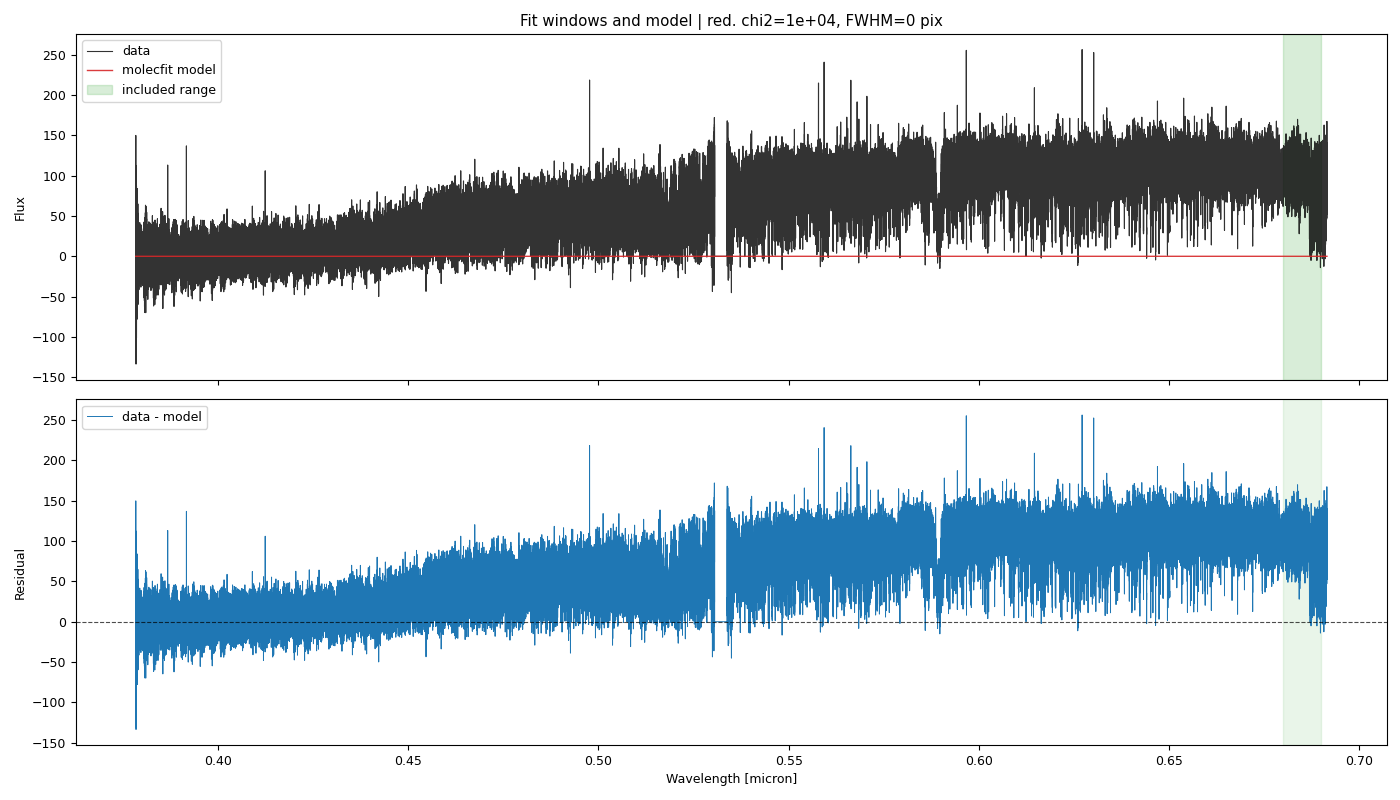

Included ranges found: 1
Excluded ranges found: 0


In [ ]:
# Extra diagnostic plot: show fit windows (included/excluded) + fit residuals

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Reuse variables from previous cell if available
# expected: run_dir, spectrum_index
if "run_dir" not in globals():
    run_dir = "/home/amasson/data/molecfit_wrapper/Output/output0__06_05_2026"
if "spectrum_index" not in globals():
    spectrum_index = 0

auto_prog_dir = "/home/amasson/data/molecfit_wrapper/Automated_Program"

def _safe_load_ranges(path):
    if path is None or (not os.path.exists(path)):
        return np.empty((0, 2))
    if os.path.getsize(path) == 0:
        return np.empty((0, 2))
    arr = np.loadtxt(path)
    arr = np.atleast_2d(arr)
    if arr.shape[1] != 2:
        arr = arr.reshape(-1, 2)
    return arr.astype(float)

def _parse_range_paths_from_par(par_path):
    inc, exc = None, None
    if not os.path.exists(par_path):
        return inc, exc
    with open(par_path, "r") as f:
        for line in f:
            if line.strip().startswith("wrange_include:"):
                inc = line.split(":", 1)[1].strip()
            elif line.strip().startswith("wrange_exclude:"):
                exc = line.split(":", 1)[1].strip()
    return inc, exc

def _find_ranges(run_dir, idx, auto_prog_dir):
    # 1) try direct local files
    candidates_inc = [
        os.path.join(run_dir, f"include_{idx}.dat"),
        os.path.join(auto_prog_dir, f"include_{idx}.dat"),
    ]
    candidates_exc = [
        os.path.join(run_dir, f"exclude_{idx}.dat"),
        os.path.join(auto_prog_dir, f"exclude_{idx}.dat"),
    ]

    # 2) try parsing path from the run par file
    par_file = os.path.join(run_dir, f"Spectrum_{idx}_fit.par")
    inc_from_par, exc_from_par = _parse_range_paths_from_par(par_file)
    if inc_from_par:
        candidates_inc.insert(0, inc_from_par)
    if exc_from_par:
        candidates_exc.insert(0, exc_from_par)

    inc = np.empty((0, 2))
    exc = np.empty((0, 2))

    for p in candidates_inc:
        inc = _safe_load_ranges(p)
        if inc.size > 0:
            break

    for p in candidates_exc:
        exc = _safe_load_ranges(p)
        # allow empty exclusion file as valid
        if p and os.path.exists(p):
            break

    return inc, exc

def _read_fit_products(run_dir, idx):
    fit_fits = os.path.join(run_dir, f"Spectrum_{idx}_fit.fits")
    with fits.open(fit_fits) as hdul:
        d = hdul[1].data
        w = np.array(d["lambda"], dtype=float)   # micron
        f = np.array(d["flux"], dtype=float)
        m = np.array(d["mflux"], dtype=float)
    return w, f, m

def _read_fit_metrics(run_dir, idx):
    res_txt = os.path.join(run_dir, f"Spectrum_{idx}_fit.res")
    out = {"redchi2": np.nan, "fwhm_pix": np.nan}
    if not os.path.exists(res_txt):
        return out
    with open(res_txt, "r") as f:
        for line in f:
            if "Reduced chi2:" in line:
                try:
                    out["redchi2"] = float(line.split()[-1])
                except Exception:
                    pass
            if "FWHM of Gaussian in pixels:" in line:
                try:
                    out["fwhm_pix"] = float(line.split()[-3])
                except Exception:
                    pass
    return out

# Load
w_fit, f_fit, f_model = _read_fit_products(run_dir, spectrum_index)
inc_ranges, exc_ranges = _find_ranges(run_dir, spectrum_index, auto_prog_dir)
metrics = _read_fit_metrics(run_dir, spectrum_index)
resid = f_fit - f_model

# Plot
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: data + model + fit windows
ax[0].plot(w_fit, f_fit, color="k", lw=0.8, alpha=0.8, label="data")
ax[0].plot(w_fit, f_model, color="tab:red", lw=1.0, alpha=0.9, label="molecfit model")

for i, (lo, hi) in enumerate(inc_ranges):
    ax[0].axvspan(lo, hi, color="tab:green", alpha=0.18, label="included range" if i == 0 else None)

for i, (lo, hi) in enumerate(exc_ranges):
    ax[0].axvspan(lo, hi, color="tab:orange", alpha=0.25, label="excluded range" if i == 0 else None)

title = f"Fit windows and model | red. chi2={metrics['redchi2']:.3g}, FWHM={metrics['fwhm_pix']:.3g} pix"
ax[0].set_title(title)
ax[0].set_ylabel("Flux")
ax[0].legend(loc="best")

# Bottom panel: residuals + same windows
ax[1].plot(w_fit, resid, color="tab:blue", lw=0.7, label="data - model")
ax[1].axhline(0.0, color="k", ls="--", lw=0.8, alpha=0.7)

for lo, hi in inc_ranges:
    ax[1].axvspan(lo, hi, color="tab:green", alpha=0.10)
for lo, hi in exc_ranges:
    ax[1].axvspan(lo, hi, color="tab:orange", alpha=0.16)

ax[1].set_xlabel("Wavelength [micron]")
ax[1].set_ylabel("Residual")
ax[1].legend(loc="best")

plt.tight_layout()
plt.show()

print(f"Included ranges found: {len(inc_ranges)}")
print(f"Excluded ranges found: {len(exc_ranges)}")


(0.0, 150.0)

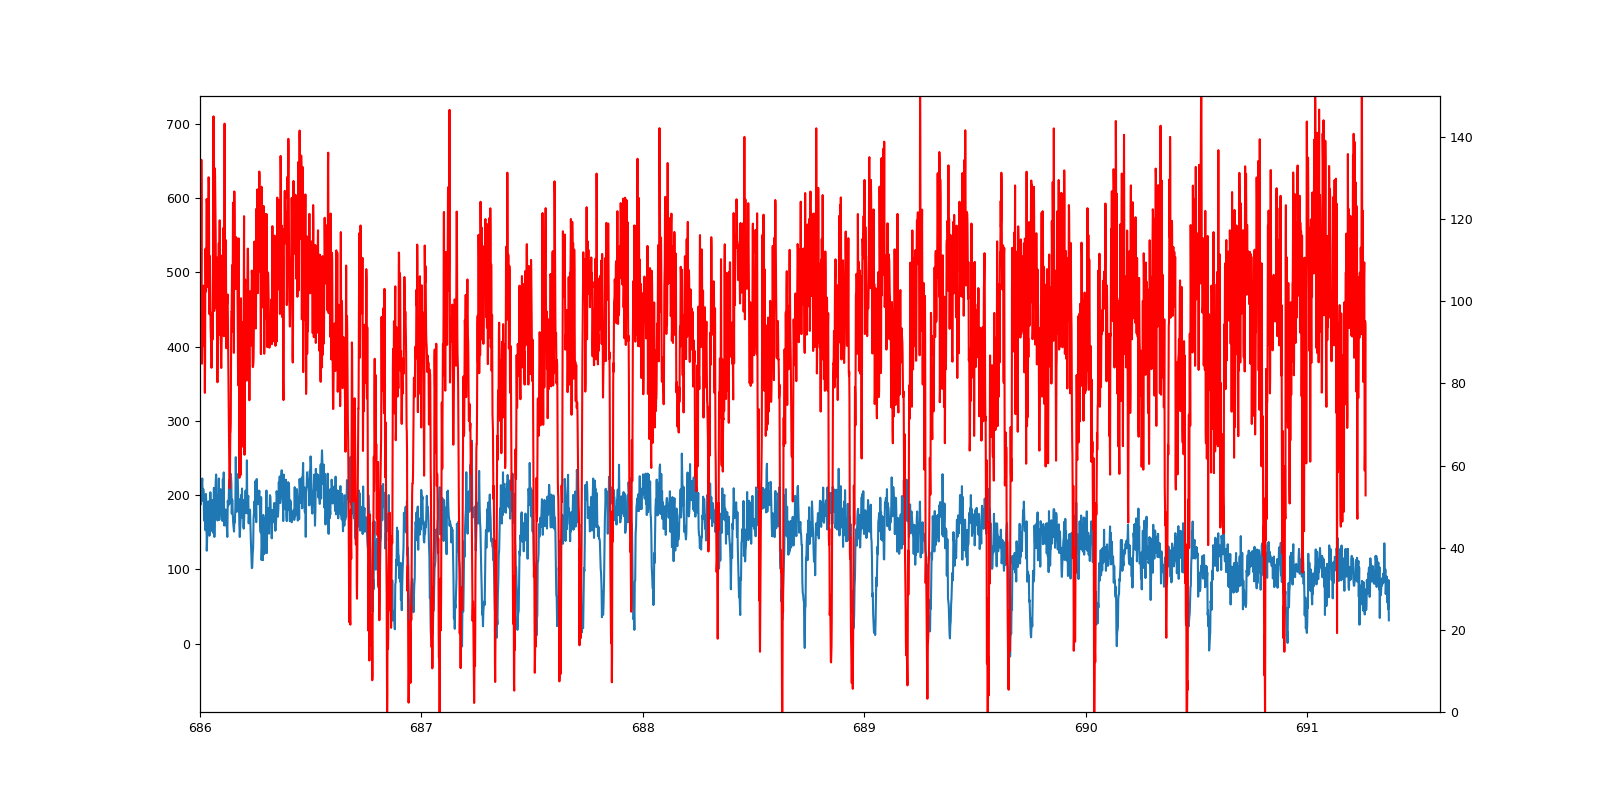

In [ ]:
# check if wavelength were built properly
from scipy.interpolate import interp1d
plt.figure(figsize=(16,8))

# plt.plot(dd.wave[0].flatten(),dd.data[0].flatten())
plt.plot(dd.wave[0].flatten()/(1-dd.Vp[0]/const.c.value),dd.data[0].flatten())

# plt.plot(dd.wave[0].flatten(),dd.data[0].flatten()) # spectrum from e2ds
plt.twinx().plot(w_in/10,f_in,'r')
plt.xlim(686,691.6)
plt.ylim(0,150)
# plt.figure()


In [ ]:
f = fits.open(dd.path+dd.files[0])


In [ ]:
f.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-03T23:59:42.310_e2ds_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3359   (4096, 72)   float32   
